# LOSO Pipeline and Training - Daphnet FoG Dataset

**Objective:** Execute complete LOSO cross-validation pipeline comparing 6 different classifiers for FoG detection.

**Classifiers tested:**
1. Logistic Regression
2. Random Forest
3. Multi-layer Perceptron (MLP)
4. AdaBoost
5. XGBoost
6. SVM (RBF kernel)

**Pipeline (using imblearn):**
1. Load extracted features per fold
2. Create pipeline: Imputation -> RandomOverSampler -> Classifier
3. Fit pipeline on train (automatically applies all steps)
4. Predict on test (automatically applies preprocessing, no oversampling)
5. Compare results across all classifiers

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

# Preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.base import clone

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score, cross_val_predict, RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# Imbalanced learning — use RandomOverSampler instead of SMOTE for extreme imbalance
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Feature Data

In [2]:
# Find all fold directories
feature_dir = Path('../../outputs/daphnet_features')
fold_dirs = sorted([d for d in feature_dir.iterdir() if d.is_dir()])

print(f"Found {len(fold_dirs)} LOSO folds")
for fold_dir in fold_dirs:
    print(f"  {fold_dir.name}")

Found 10 LOSO folds
  fold_subj_S01
  fold_subj_S02
  fold_subj_S03
  fold_subj_S04
  fold_subj_S05
  fold_subj_S06
  fold_subj_S07
  fold_subj_S08
  fold_subj_S09
  fold_subj_S10


In [3]:
# Load first fold as example
fold_0_dir = fold_dirs[0]

X_train_fold0 = pd.read_csv(fold_0_dir / 'X_train_features.csv')
y_train_fold0 = pd.read_csv(fold_0_dir / 'y_train.csv').squeeze()
X_test_fold0 = pd.read_csv(fold_0_dir / 'X_test_features.csv')
y_test_fold0 = pd.read_csv(fold_0_dir / 'y_test.csv').squeeze()

print(f"Fold 0 - {fold_0_dir.name}")
print(f"  X_train: {X_train_fold0.shape}")
print(f"  y_train: {y_train_fold0.shape} | Distribution: {np.bincount(y_train_fold0)}")
print(f"  X_test: {X_test_fold0.shape}")
print(f"  y_test: {y_test_fold0.shape} | Distribution: {np.bincount(y_test_fold0)}")
print(f"\nFeatures: {X_train_fold0.shape[1]}")

Fold 0 - fold_subj_S01
  X_train: (10596, 337)
  y_train: (10596,) | Distribution: [9186 1410]
  X_test: (633, 337)
  y_test: (633,) | Distribution: [581  52]

Features: 337


In [4]:
# Helper function to clean inf/nan values before imputation
def clean_features(X):
    """Replace inf/-inf with NaN so KNNImputer can handle them."""
    X_clean = X.copy()
    X_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    return X_clean

print("✅ Helper function loaded")

✅ Helper function loaded


## 2. Define Classifiers

We'll test 6 different classifiers with optimized hyperparameters.

In [5]:
# Define all classifiers to test
# Improvements over baseline:
#   - class_weight='balanced': up-weights minority class (FoG) in the loss function
#   - XGBoost scale_pos_weight: set per fold inside the LOSO loop (ratio neg/pos)
#   - SVC probability=True: enables predict_proba for threshold optimization
#   - AdaBoost tuned to be more stable on noisy splits (lower lr, SAMME)
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        random_state=42,
        early_stopping=True
    ),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
        n_estimators=150,
        learning_rate=0.05,
        algorithm='SAMME',
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
        # scale_pos_weight is set per fold inside the LOSO loop
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        random_state=42,
        class_weight='balanced',
        probability=True  # required for threshold optimization
    )
}

print("Classifiers to test:")
for i, (name, clf) in enumerate(classifiers.items(), 1):
    print(f"  {i}. {name}")
print(f"\nTotal: {len(classifiers)} classifiers")
print("\nImprovements applied:")
print("  ✓ class_weight='balanced'       → Logistic Regression, Random Forest, SVM")
print("  ✓ base estimator class_weight   → AdaBoost (DecisionTree max_depth=1)")
print("  ✓ AdaBoost stability tweaks      → lower lr + SAMME")
print("  ✓ scale_pos_weight (per fold)   → XGBoost")
print("  ✓ probability=True              → SVM (enables threshold optimization)")

Classifiers to test:
  1. Logistic Regression
  2. Random Forest
  3. MLP
  4. AdaBoost
  5. XGBoost
  6. SVM

Total: 6 classifiers

Improvements applied:
  ✓ class_weight='balanced'       → Logistic Regression, Random Forest, SVM
  ✓ base estimator class_weight   → AdaBoost (DecisionTree max_depth=1)
  ✓ AdaBoost stability tweaks      → lower lr + SAMME
  ✓ scale_pos_weight (per fold)   → XGBoost
  ✓ probability=True              → SVM (enables threshold optimization)


## 3. Test All Classifiers (Single Fold)

Quick test on Fold 0 to compare all classifiers.

In [ ]:
# Test all classifiers on Fold 0
print("Testing all classifiers on Fold 0...")
print("=" * 70)

X_train_clean = clean_features(X_train_fold0)
X_test_clean = clean_features(X_test_fold0)

fold0_results = []

for clf_name, clf in classifiers.items():
    pipeline = ImbPipeline([
        ('imputer',    KNNImputer(n_neighbors=5)),
        ('oversampler', RandomOverSampler(random_state=42)),
        ('classifier', clf)
    ])

    pipeline.fit(X_train_clean, y_train_fold0)
    y_pred = pipeline.predict(X_test_clean)

    fold0_results.append({
        'Classifier': clf_name,
        'Accuracy':   accuracy_score(y_test_fold0, y_pred),
        'Precision':  precision_score(y_test_fold0, y_pred, average='binary'),
        'Recall':     recall_score(y_test_fold0, y_pred, average='binary'),
        'F1':         f1_score(y_test_fold0, y_pred, average='binary')
    })

fold0_df = pd.DataFrame(fold0_results).sort_values('F1', ascending=False)

print("\nFold 0 Results (sorted by F1):")
print(fold0_df.to_string(index=False))
print("\n" + "=" * 70)

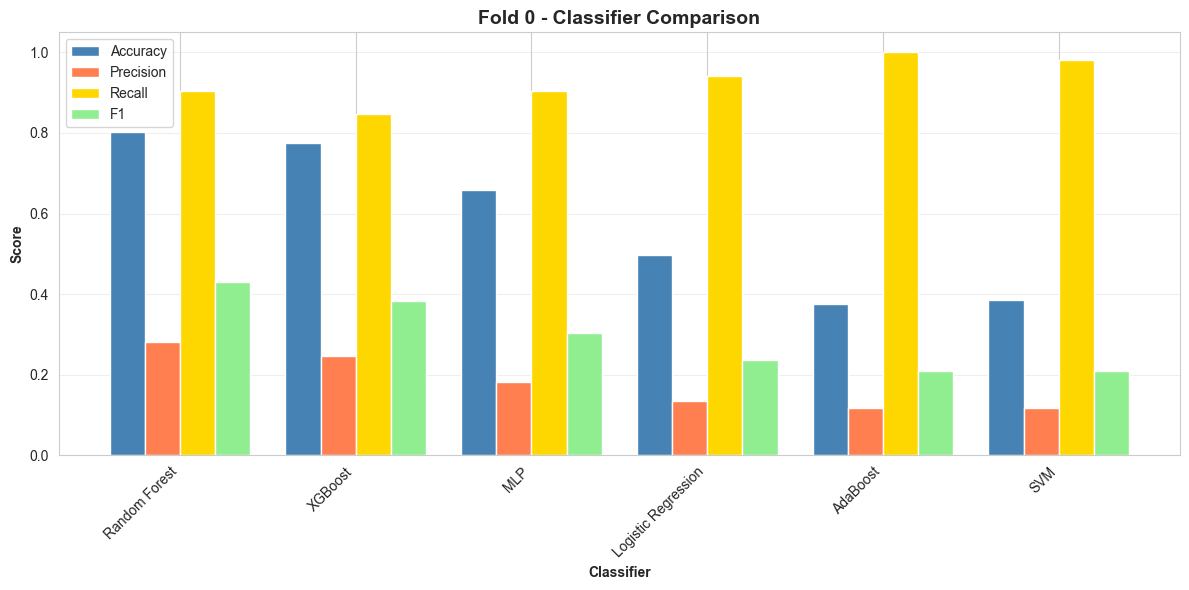

In [7]:
# Visualize Fold 0 comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fold0_df))
width = 0.2

ax.bar(x - 1.5*width, fold0_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, fold0_df['Precision'], width, label='Precision', color='coral')
ax.bar(x + 0.5*width, fold0_df['Recall'], width, label='Recall', color='gold')
ax.bar(x + 1.5*width, fold0_df['F1'], width, label='F1', color='lightgreen')

ax.set_xlabel('Classifier', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Fold 0 - Classifier Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fold0_df['Classifier'], rotation=45, ha='right')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Show RandomOverSampler effect (using first classifier as example)
first_clf = list(classifiers.values())[0]

pipeline = ImbPipeline([
    ('imputer',    KNNImputer(n_neighbors=5)),
    ('oversampler', RandomOverSampler(random_state=42)),
    ('classifier', first_clf)
])

# Transform data up to oversampler step
X_train_fold0_clean = clean_features(X_train_fold0)
X_imputed = pipeline.named_steps['imputer'].fit_transform(X_train_fold0_clean)
X_resampled, y_resampled = pipeline.named_steps['oversampler'].fit_resample(X_imputed, y_train_fold0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

original_dist = np.bincount(y_train_fold0)
axes[0].bar(['No FoG', 'FoG'], original_dist, color=['steelblue', 'coral'])
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Before RandomOverSampler (Train)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(original_dist):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

resampled_dist = np.bincount(y_resampled)
axes[1].bar(['No FoG', 'FoG'], resampled_dist, color=['steelblue', 'coral'])
axes[1].set_ylabel('Sample Count')
axes[1].set_title('After RandomOverSampler (Train)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(resampled_dist):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Original:               {len(y_train_fold0):,} samples")
print(f"After RandomOverSampler: {len(y_resampled):,} samples (+{len(y_resampled) - len(y_train_fold0):,})")
print(f"\nRandomOverSampler duplicates minority samples (safer than SMOTE for extreme imbalance)")

## Feature Selection Analysis

Before running the full LOSO pipeline, we analyze which features best discriminate FoG from normal gait. This guides the choice of `k` in `SelectKBest(f_classif, k=K_BEST)`, embedded **inside** the pipeline — applied independently on each fold's training data (no data leakage).

| Method | Type | What it measures |
|--------|------|-----------------|
| **Mutual Information** | Non-parametric | Non-linear statistical dependency between feature and label |
| **ANOVA F-Score** | Parametric | Linear separability between class distributions |
| **Random Forest MDI** | Tree-based | Feature importance via mean decrease in impurity |
| **Correlation Analysis** | Redundancy | Identifies near-duplicate features among the top-k |
| **Cross-validation over k** | Empirical | Selects optimal k using 5-fold CV on fold-0 training data |

In [9]:
# Load all training folds combined (for exploratory analysis only)
# SelectKBest will be applied INSIDE the LOSO pipeline → no data leakage per fold
print("Loading combined training data for feature selection analysis...")
print("(SelectKBest is applied inside the LOSO pipeline, not here → no leakage)\n")

all_X_list, all_y_list = [], []
for fold_dir in fold_dirs:
    X = clean_features(pd.read_csv(fold_dir / 'X_train_features.csv'))
    y = pd.read_csv(fold_dir / 'y_train.csv').squeeze()
    all_X_list.append(X)
    all_y_list.append(y)

X_all = pd.concat(all_X_list).reset_index(drop=True)
y_all = pd.concat(all_y_list).reset_index(drop=True)

imputer_fs = KNNImputer(n_neighbors=5)
X_all_imp = pd.DataFrame(
    imputer_fs.fit_transform(X_all), columns=X_all.columns)
n_features_total = X_all_imp.shape[1]

print(f"Combined training set: {X_all_imp.shape}")
print(f"Class distribution:    {dict(zip(['Non-FoG', 'FoG'], np.bincount(y_all)))}")

# --- 1. Univariate: ANOVA F-score + Mutual Information ---
print("\nComputing ANOVA F-scores and Mutual Information...")
f_scores, f_pvalues = f_classif(X_all_imp, y_all)
f_scores = np.nan_to_num(f_scores)
mi_scores = mutual_info_classif(X_all_imp, y_all, random_state=42)

feature_scores_df = pd.DataFrame({
    'feature':  X_all_imp.columns,
    'mi_score': mi_scores,
    'f_score':  f_scores,
    'f_pvalue': f_pvalues,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

n_significant = (f_pvalues < 0.05).sum()
print(f"Significant features (ANOVA p < 0.05): {n_significant} / {n_features_total}")

# --- 2. Random Forest importance ---
print("\nTraining Random Forest for feature importance (n_estimators=200)...")
rf_fs = RandomForestClassifier(n_estimators=200, max_depth=15,
                               random_state=42, n_jobs=-1)
rf_fs.fit(X_all_imp, y_all)

rf_imp_df = pd.DataFrame({
    'feature':    X_all_imp.columns,
    'importance': rf_fs.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
rf_imp_df['cumulative'] = rf_imp_df['importance'].cumsum()

k_90 = int((rf_imp_df['cumulative'] <= 0.90).sum()) + 1
k_95 = int((rf_imp_df['cumulative'] <= 0.95).sum()) + 1

print(f"Features for 90% cumulative importance: {k_90}")
print(f"Features for 95% cumulative importance: {k_95}")
print(f"\nTop 10 by RF importance:")
print(rf_imp_df.head(10)[['feature', 'importance']].to_string(index=False))

Loading combined training data for feature selection analysis...
(SelectKBest is applied inside the LOSO pipeline, not here → no leakage)

Combined training set: (106740, 337)
Class distribution:    {'Non-FoG': 93114, 'FoG': 13626}

Computing ANOVA F-scores and Mutual Information...


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [260] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Significant features (ANOVA p < 0.05): 304 / 337

Training Random Forest for feature importance (n_estimators=200)...
Features for 90% cumulative importance: 253
Features for 95% cumulative importance: 289

Top 10 by RF importance:
                            feature  importance
          ch1_locomotion_band_index    0.016747
                     ch0_higuchi_fd    0.016674
          ch0_locomotion_band_index    0.016121
acc_ankle_mag_locomotion_band_index    0.015212
           acc_ankle_mag_higuchi_fd    0.014305
                 ch0_freezing_index    0.014047
                  ch0_psd_peak_freq    0.013481
                 ch1_freezing_index    0.012705
       acc_ankle_mag_freezing_index    0.012676
                           ch0_mean    0.010473


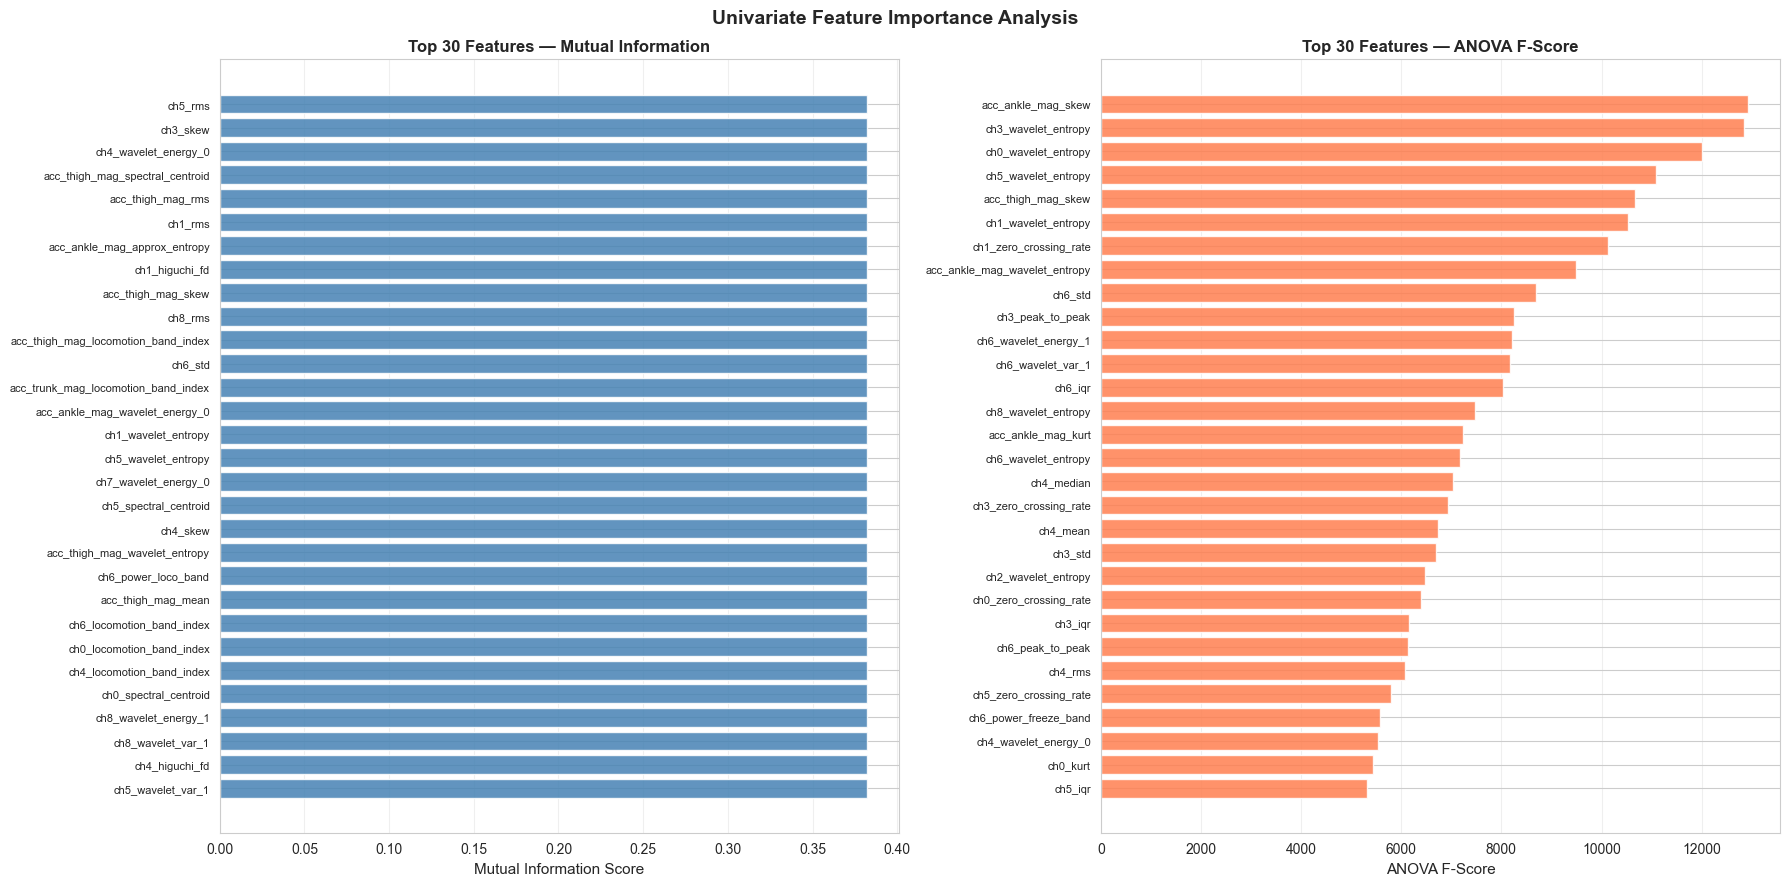

In [10]:
# --- Plot: Mutual Information and ANOVA F-scores ---
top_n = 30
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top_mi = feature_scores_df.head(top_n)
axes[0].barh(range(top_n), top_mi['mi_score'].values[::-1],
             color='steelblue', alpha=0.85)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_mi['feature'].values[::-1], fontsize=8)
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title(f'Top {top_n} Features — Mutual Information',
                  fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

top_f = feature_scores_df.sort_values('f_score', ascending=False).head(top_n)
axes[1].barh(range(top_n), top_f['f_score'].values[::-1],
             color='coral', alpha=0.85)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_f['feature'].values[::-1], fontsize=8)
axes[1].set_xlabel('ANOVA F-Score', fontsize=11)
axes[1].set_title(f'Top {top_n} Features — ANOVA F-Score',
                  fontweight='bold', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Univariate Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

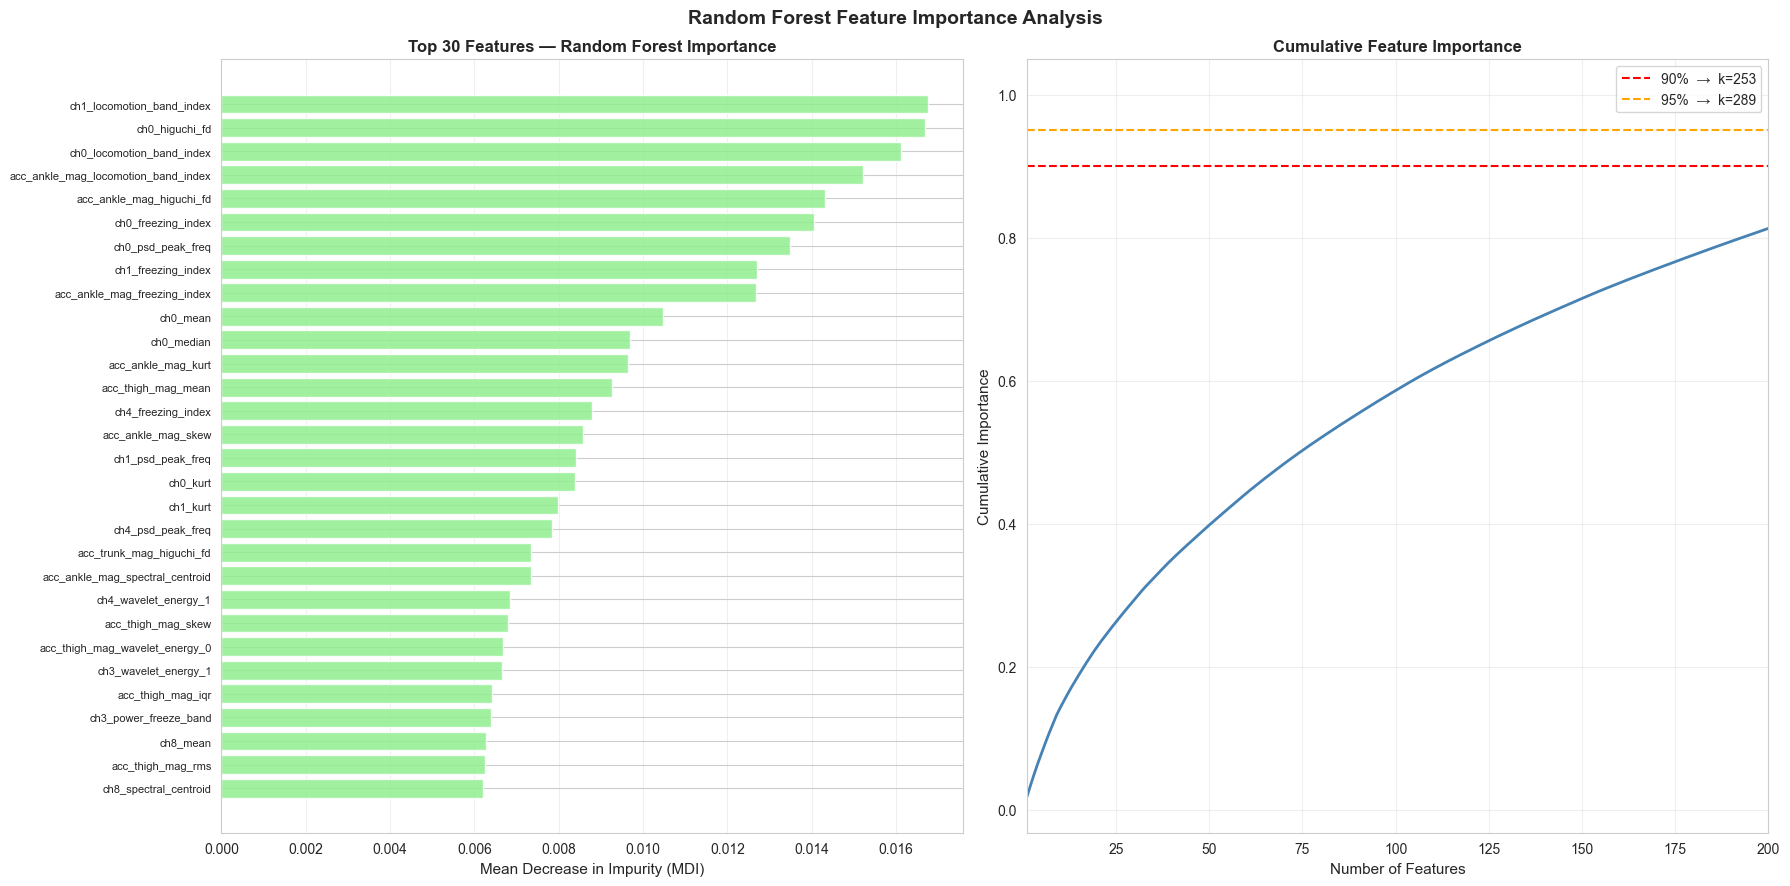

In [11]:
# --- Plot: RF importance + cumulative importance ---
top_n = 30
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top_rf = rf_imp_df.head(top_n)
axes[0].barh(range(top_n), top_rf['importance'].values[::-1],
             color='lightgreen', alpha=0.85)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_rf['feature'].values[::-1], fontsize=8)
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
axes[0].set_title(f'Top {top_n} Features — Random Forest Importance',
                  fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

x_lim = min(n_features_total, 200)
axes[1].plot(range(1, n_features_total + 1), rf_imp_df['cumulative'],
             color='steelblue', linewidth=2)
axes[1].axhline(y=0.90, color='red',    linestyle='--', linewidth=1.5,
                label=f'90%  →  k={k_90}')
axes[1].axhline(y=0.95, color='orange', linestyle='--', linewidth=1.5,
                label=f'95%  →  k={k_95}')
axes[1].axvline(x=k_90, color='red',    linestyle=':', alpha=0.7)
axes[1].axvline(x=k_95, color='orange', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].set_xlim([1, x_lim])
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Random Forest Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Highly correlated pairs (|r| > 0.90) among top-40 features: 6
  ch3_wavelet_energy_1                          ↔  ch3_wavelet_var_1                              r=1.000
  ch4_wavelet_energy_1                          ↔  ch4_wavelet_var_1                              r=1.000
  ch8_mean                                      ↔  ch8_median                                     r=0.997
  ch0_mean                                      ↔  ch0_median                                     r=0.968
  ch1_locomotion_band_index                     ↔  acc_ankle_mag_locomotion_band_index            r=0.940
  acc_ankle_mag_higuchi_fd                      ↔  acc_ankle_mag_spectral_centroid                r=0.938


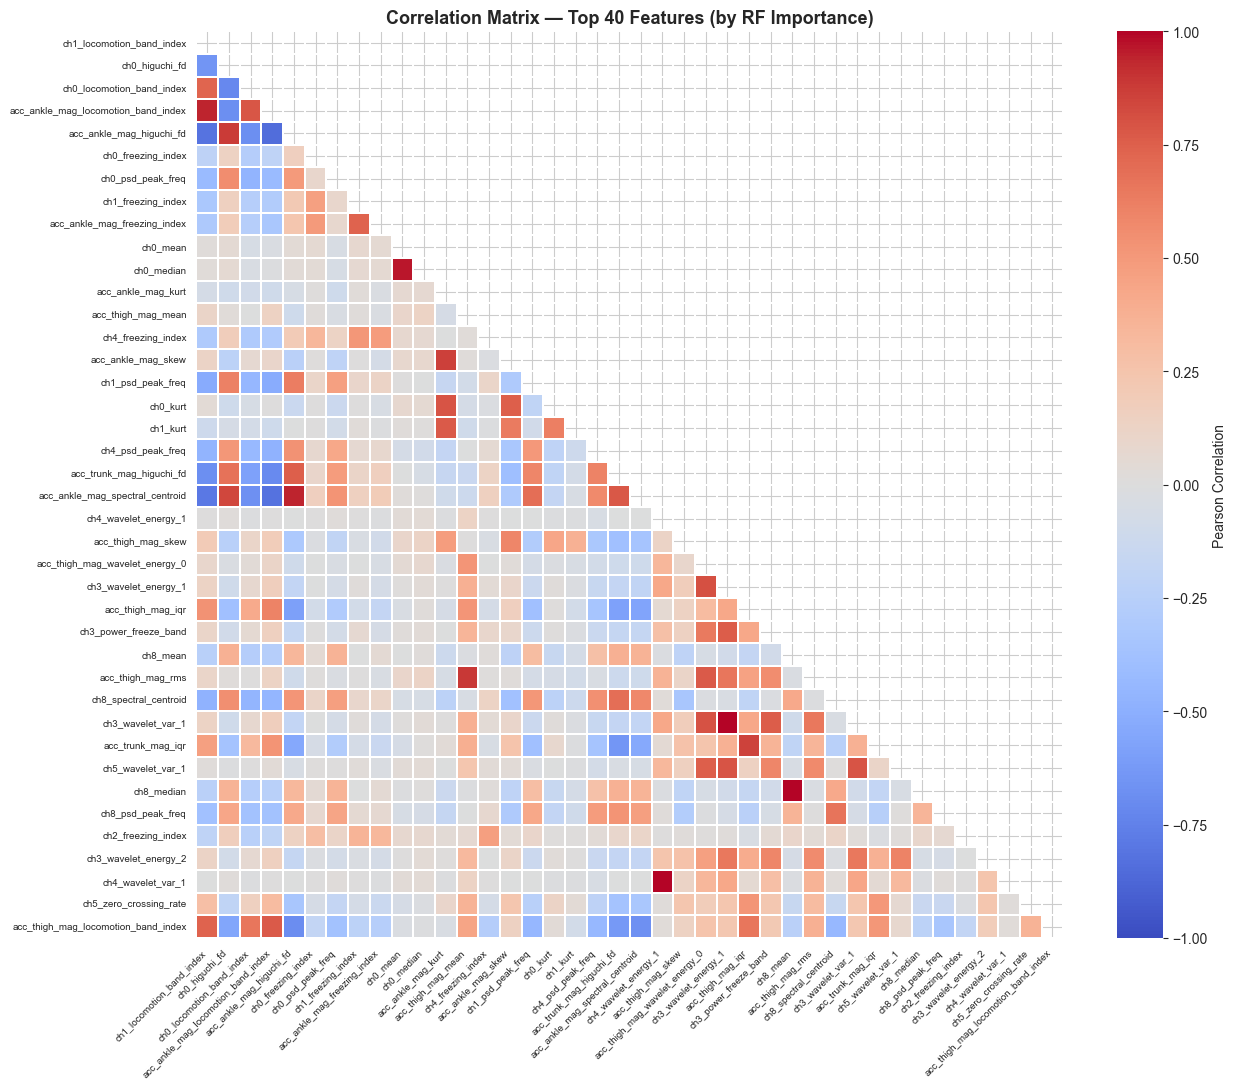

SelectKBest retains only the top-k by F-score, effectively filtering redundant features.


In [12]:
# --- Correlation analysis among top features ---
top_corr_n = 40
top_features = rf_imp_df.head(top_corr_n)['feature'].tolist()
corr_matrix = X_all_imp[top_features].corr()

# Find highly correlated pairs (|r| > 0.90)
high_corr = [
    {'f1': top_features[i], 'f2': top_features[j], 'r': corr_matrix.iloc[i, j]}
    for i in range(len(top_features))
    for j in range(i + 1, len(top_features))
    if abs(corr_matrix.iloc[i, j]) > 0.90
]

print(f"Highly correlated pairs (|r| > 0.90) among top-{top_corr_n} features: {len(high_corr)}")
for d in sorted(high_corr, key=lambda x: abs(x['r']), reverse=True)[:8]:
    print(f"  {d['f1']:45s} ↔  {d['f2']:45s}  r={d['r']:.3f}")

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.2,
            cbar_kws={'label': 'Pearson Correlation'},
            vmin=-1, vmax=1, ax=ax)
ax.set_title(f'Correlation Matrix — Top {top_corr_n} Features (by RF Importance)',
             fontweight='bold', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()
print("SelectKBest retains only the top-k by F-score, effectively filtering redundant features.")

In [13]:
import re
from sklearn.base import BaseEstimator, TransformerMixin

# --- Sensor mapping: Daphnet (ankle + thigh + trunk IMUs, acc only) ---
# Defined here so SensorSelectKBest can be used inside the LOSO pipeline.
# Section 7 redefines these identically for visualization — harmless.
CH_TO_SENSOR = {i: s for s, chs in [
    ('Ankle', [0, 1, 2]),
    ('Thigh', [3, 4, 5]),
    ('Trunk', [6, 7, 8]),
] for i in chs}
MAG_TO_SENSOR = {
    'acc_ankle_mag': 'Ankle',
    'acc_thigh_mag': 'Thigh',
    'acc_trunk_mag': 'Trunk',
}

def get_sensor(feat):
    m = re.match(r'^ch(\d+)_', feat)
    if m: return CH_TO_SENSOR.get(int(m.group(1)), 'Global')
    for prefix, s in MAG_TO_SENSOR.items():
        if feat.startswith(prefix + '_'): return s
    return 'Global'
# Build sensor → column list from X_all_imp (computed in exploratory section above)
sensor_col_map = {}
for col in X_all_imp.columns:
    sensor_col_map.setdefault(get_sensor(col), []).append(col)

print('Sensor groups:')
for s, cols in sensor_col_map.items():
    print(f'  {s}: {len(cols)} features')


class SensorSelectKBest(BaseEstimator, TransformerMixin):
    """
    ANOVA SelectKBest applied independently per sensor group.
    Equal quota: k_per_sensor features per sensor. sklearn-compatible
    (k_per_sensor is tunable via RandomizedSearchCV).
    Requires DataFrame input (preserves column names through the pipeline).
    Handles missing values using train-fold medians per feature.
    """
    def __init__(self, sensor_col_map, k_per_sensor=10):
        self.sensor_col_map = sensor_col_map
        self.k_per_sensor   = k_per_sensor

    def fit(self, X, y):
        self.selected_cols_ = []
        self.fill_values_ = {}
        for sensor, cols in self.sensor_col_map.items():
            valid = [c for c in cols if c in X.columns]
            if not valid:
                continue
            X_valid = X[valid].copy()
            medians = X_valid.median(axis=0, numeric_only=True)
            medians = medians.fillna(0.0)
            X_valid = X_valid.fillna(medians)
            for col in valid:
                self.fill_values_[col] = float(medians[col])
            k = min(self.k_per_sensor, len(valid))
            sel = SelectKBest(f_classif, k=k)
            sel.fit(X_valid.values, y)
            self.selected_cols_.extend(
                [valid[i] for i, ok in enumerate(sel.get_support()) if ok]
            )
        return self

    def transform(self, X):
        X_sel = X[self.selected_cols_].copy()
        for col in self.selected_cols_:
            X_sel[col] = X_sel[col].fillna(self.fill_values_.get(col, 0.0))
        return X_sel

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_cols_)

print('\u2705 Per-sensor setup ready')


Sensor groups:
  Ankle: 112 features
  Thigh: 112 features
  Trunk: 112 features
  Global: 1 features
✅ Per-sensor setup ready


In [ ]:
print("Finding optimal k_per_sensor via 5-Fold StratifiedCV on fold-0 training data...")
k_candidates = [3, 5, 8, 10, 15]

X_tr0_raw = clean_features(pd.read_csv(fold_dirs[0] / 'X_train_features.csv'))
y_tr0     = pd.read_csv(fold_dirs[0] / 'y_train.csv').squeeze()

rf_quick = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
cv5      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for k_s in k_candidates:
    pipe_k = ImbPipeline([
        ('selector', SensorSelectKBest(sensor_col_map=sensor_col_map, k_per_sensor=k_s)),
        ('imputer',  KNNImputer(n_neighbors=5)),
        ('oversampler', RandomOverSampler(random_state=42)),
        ('clf',      rf_quick),
    ])
    f1_cv  = cross_val_score(pipe_k, X_tr0_raw, y_tr0, cv=cv5, scoring='f1', n_jobs=-1)
    bal_cv = cross_val_score(pipe_k, X_tr0_raw, y_tr0, cv=cv5,
                             scoring='balanced_accuracy', n_jobs=-1)
    n_sel = len(SensorSelectKBest(sensor_col_map, k_s).fit(X_tr0_raw, y_tr0).selected_cols_)
    cv_results.append({'k_per_sensor': k_s, 'n_total': n_sel,
                       'f1_mean': f1_cv.mean(), 'f1_std': f1_cv.std(),
                       'bal_mean': bal_cv.mean()})
    print(f"  k={k_s:2d} -> {n_sel:3d} features   "
          f"F1={f1_cv.mean():.3f}+/-{f1_cv.std():.3f}   BalAcc={bal_cv.mean():.3f}")

cv_df = pd.DataFrame(cv_results)
K_PER_SENSOR = int(cv_df.loc[cv_df['f1_mean'].idxmax(), 'k_per_sensor'])

# Search range for RSCV tuning (neighbours of K_PER_SENSOR)
k_search = sorted(set([max(3, K_PER_SENSOR - 3), K_PER_SENSOR,
                        min(15, K_PER_SENSOR + 5)]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar([r['k_per_sensor'] for r in cv_results], [r['f1_mean'] for r in cv_results],
            yerr=[r['f1_std'] for r in cv_results],
            fmt='o-', color='steelblue', capsize=4, linewidth=2, label='F1 Score')
ax.errorbar([r['k_per_sensor'] for r in cv_results], [r['bal_mean'] for r in cv_results],
            fmt='s--', color='coral', capsize=4, linewidth=2, label='Balanced Accuracy')
ax.axvline(x=K_PER_SENSOR, color='green', linestyle=':', linewidth=2.5,
           label=f'K_PER_SENSOR = {K_PER_SENSOR}')
ax.set_xlabel('k per sensor', fontsize=12, fontweight='bold')
ax.set_ylabel('5-Fold CV Score', fontsize=12, fontweight='bold')
ax.set_title('Choosing Optimal k_per_sensor\n'
             '(5-Fold StratifiedCV - Quick RF - Fold-0 Training Data)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"\nK_PER_SENSOR = {K_PER_SENSOR}  |  k_search for RSCV = {k_search}")

In [ ]:
# ===========================================================================
# Hyperparameter grids (prefixed with 'classifier__' for ImbPipeline step)
# ===========================================================================
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    },
    'Random Forest': {
        'classifier__n_estimators':     [100, 200, 300],
        'classifier__max_depth':        [5, 10, 15, 20, None],
        'classifier__min_samples_leaf': [1, 2, 4, 8],
        'classifier__max_features':     ['sqrt', 'log2'],
    },
    'MLP': {
        'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (256, 128)],
        'classifier__alpha':              [1e-5, 1e-4, 1e-3, 1e-2],
        'classifier__learning_rate_init': [1e-3, 5e-4, 1e-4],
    },
    'AdaBoost': {
        'classifier__n_estimators':  [50, 100, 150, 200],
        'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'classifier__algorithm':     ['SAMME']
    },
    'XGBoost': {
        'classifier__n_estimators':     [100, 200, 300],
        'classifier__max_depth':        [3, 5, 6, 8],
        'classifier__learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'classifier__subsample':        [0.7, 0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.7, 0.8, 1.0],
        'classifier__min_child_weight': [1, 3, 5],
    },
    'SVM': {
        'classifier__C':     [0.01, 0.1, 1, 10, 100, 1000],
        'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    },
}

# Tracking: feature selection frequency and best hyperparameters per classifier
feature_counts  = {col: 0 for col in X_all_imp.columns}
best_params_log = {clf_name: [] for clf_name in classifiers}

# ===========================================================================
# Run complete LOSO pipeline for all classifiers
# Principles enforced:
#   1. No leakage: all transforms/selection/sampling happen inside pipeline
#   2. Group-aware inner CV (GroupKFold by subject) to avoid optimistic bias
#   3. Stable imbalance handling: RandomOverSampler (safer than SMOTE for extreme imbalance)
#   4. Per-subject normalization done with training subjects only
#   5. Constant-feature removal uses training fold only and is applied to test
# ===========================================================================
print("Running LOSO pipeline for all classifiers...")
print(f"Pipeline: per-subj-norm -> remove-constant-features(train-only) -> "
      f"SensorSelectKBest(k in {k_search}/sensor) -> KNNImputer -> RandomOverSampler -> Classifier")
print("HP tuning : RandomizedSearchCV (inner GroupKFold by subject)")
print("Threshold : OOF proba on training set (group-aware CV) -> PR curve -> argmax F1")
print("=" * 70)

all_results = {clf_name: [] for clf_name in classifiers.keys()}

for fold_dir in tqdm(fold_dirs, desc="Processing folds"):
    fold_name = fold_dir.name

    X_train = clean_features(pd.read_csv(fold_dir / 'X_train_features.csv'))
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze()
    X_test  = clean_features(pd.read_csv(fold_dir / 'X_test_features.csv'))
    y_test  = pd.read_csv(fold_dir / 'y_test.csv').squeeze()

    # Remove constant features using training fold only (no leakage)
    constant_cols = X_train.columns[X_train.nunique(dropna=False) <= 1]
    if len(constant_cols) > 0:
        X_train = X_train.drop(columns=constant_cols)
        X_test  = X_test.drop(columns=constant_cols, errors='ignore')

    if X_train.shape[1] == 0:
        print(f"  {fold_name}: all features became constant. Skipping fold.")
        continue

    # Fold-specific sensor map after column filtering
    available_cols = set(X_train.columns)
    sensor_col_map_fold = {
        sensor: [col for col in cols if col in available_cols]
        for sensor, cols in sensor_col_map.items()
    }

    # --- Per-subject normalization (reduces inter-subject scale differences) ---
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze().values
    X_train_arr    = X_train.values.copy().astype(float)
    X_test_arr     = X_test.values.copy().astype(float)

    subj_means, subj_stds = [], []
    for subj in np.unique(subjects_train):
        mask  = subjects_train == subj
        mu    = X_train_arr[mask].mean(axis=0)
        sigma = X_train_arr[mask].std(axis=0) + 1e-8
        X_train_arr[mask] = (X_train_arr[mask] - mu) / sigma
        subj_means.append(mu)
        subj_stds.append(sigma)

    counts     = np.array([np.sum(subjects_train == s) for s in np.unique(subjects_train)])
    mean_mu    = np.average(subj_means, weights=counts, axis=0)
    mean_sigma = np.average(subj_stds,  weights=counts, axis=0)
    X_test_arr = (X_test_arr - mean_mu) / mean_sigma

    X_train_n = pd.DataFrame(X_train_arr, columns=X_train.columns)
    X_test_n  = pd.DataFrame(X_test_arr,  columns=X_test.columns)

    n_groups = len(np.unique(subjects_train))
    if n_groups < 2:
        print(f"  {fold_name}: not enough training subjects for inner CV. Skipping fold.")
        continue
    inner_splits = min(3, n_groups)
    cv_inner = GroupKFold(n_splits=inner_splits)

    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    spw   = n_neg / n_pos if n_pos > 0 else 1.0

    for clf_name, clf in classifiers.items():
        if clf_name == 'XGBoost':
            clf = clone(clf)
            clf.set_params(scale_pos_weight=spw)

        pipeline = ImbPipeline([
            ('selector',   SensorSelectKBest(sensor_col_map=sensor_col_map_fold, k_per_sensor=K_PER_SENSOR)),
            ('imputer',    KNNImputer(n_neighbors=5)),
            ('oversampler', RandomOverSampler(random_state=42)),
            ('classifier', clf)
        ])

        selector_grid = {'selector__k_per_sensor': k_search}
        clf_grid      = param_grids.get(clf_name, {})
        combined_grid = {**selector_grid, **clf_grid}

        rscv = RandomizedSearchCV(
            pipeline, combined_grid, n_iter=20, cv=cv_inner,
            scoring='f1', n_jobs=-1, random_state=42, refit=True,
            error_score=np.nan
        )
        try:
            rscv.fit(X_train_n, y_train, groups=subjects_train)
        except ValueError as exc:
            print(f"  {clf_name} failed on {fold_name}: {exc}. Skipping.")
            continue

        if not hasattr(rscv, 'best_estimator_'):
            print(f"  {clf_name} has no valid model on {fold_name}. Skipping.")
            continue

        best_pipeline = rscv.best_estimator_
        best_params_log[clf_name].append(rscv.best_params_)

        try:
            y_proba_oof = cross_val_predict(
                best_pipeline, X_train_n, y_train,
                cv=cv_inner, groups=subjects_train, method='predict_proba', n_jobs=-1
            )[:, 1]
            precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_train, y_proba_oof)
            f1_by_thresh = 2 * precisions_pr * recalls_pr / (precisions_pr + recalls_pr + 1e-9)
            if len(thresholds_pr) > 0:
                best_thresh = float(np.clip(thresholds_pr[np.argmax(f1_by_thresh[:-1])], 0.05, 0.95))
            else:
                best_thresh = 0.5

            best_pipeline.fit(X_train_n, y_train)

            for col in best_pipeline.named_steps['selector'].selected_cols_:
                feature_counts[col] += 1

            y_proba_test = best_pipeline.predict_proba(X_test_n)[:, 1]
            y_pred       = (y_proba_test >= best_thresh).astype(int)
        except ValueError as exc:
            print(f"  {clf_name} failed during OOF/fit on {fold_name}: {exc}. Skipping.")
            continue

        # Compute specificity from confusion matrix
        cm_fold = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()
        specificity = tn_f / (tn_f + fp_f) if (tn_f + fp_f) > 0 else 0.0

        all_results[clf_name].append({
            'fold':         fold_name,
            'accuracy':     accuracy_score(y_test, y_pred),
            'balanced_acc': balanced_accuracy_score(y_test, y_pred),
            'precision':    precision_score(y_test, y_pred, average='binary', zero_division=0),
            'recall':       recall_score(y_test, y_pred, average='binary', zero_division=0),
            'specificity':  specificity,
            'f1':           f1_score(y_test, y_pred, average='binary', zero_division=0),
            'threshold':    best_thresh,
            'cm':           cm_fold,
            'n_train':      len(y_train),
            'n_test':       len(y_test),
            'n_fog_test':   int((y_test == 1).sum()),
        })

print("\n" + "=" * 70)
print("LOSO pipeline complete for all classifiers")
print("=" * 70)

## 5. Comparative Results Analysis

Compare performance across all classifiers.

In [ ]:
# Compute aggregate metrics for each classifier from the accumulated confusion matrix.
summary_rows = []

for clf_name, results in all_results.items():
    if len(results) == 0:
        continue

    results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'cm'} for r in results])

    # Aggregate CM across all folds
    cm_total = np.zeros((2, 2), dtype=int)
    for r in results:
        cm_total += r['cm']
    tn, fp, fn, tp = cm_total.ravel()
    total = cm_total.sum()

    agg_acc     = (tp + tn) / total if total > 0 else 0.0
    agg_prec    = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    agg_recall  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    agg_f1      = 2 * agg_prec * agg_recall / (agg_prec + agg_recall) if (agg_prec + agg_recall) > 0 else 0.0
    agg_spec    = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    agg_bal_acc = (agg_recall + agg_spec) / 2

    summary_rows.append({
        'Classifier':    clf_name,
        'Accuracy':      f"{agg_acc:.4f} +/- {results_df['accuracy'].std():.4f}",
        'Balanced Acc':  f"{agg_bal_acc:.4f} +/- {results_df['balanced_acc'].std():.4f}",
        'Precision':     f"{agg_prec:.4f} +/- {results_df['precision'].std():.4f}",
        'Recall':        f"{agg_recall:.4f} +/- {results_df['recall'].std():.4f}",
        'Specificity':   f"{agg_spec:.4f} +/- {results_df['specificity'].std():.4f}" if 'specificity' in results_df else f"{agg_spec:.4f}",
        'F1':            f"{agg_f1:.4f} +/- {results_df['f1'].std():.4f}",
    })

summary_df = pd.DataFrame(summary_rows)

# Sort by aggregate F1 (extract numeric part)
summary_df['_f1_sort'] = summary_df['F1'].str.split(' ').str[0].astype(float)
summary_df = summary_df.sort_values('_f1_sort', ascending=False).drop(columns=['_f1_sort'])

print("=" * 110)
print("AGGREGATE RESULTS - Sorted by F1 Score")
print("Mean = aggregated over all test samples | Std = per-fold variability")
print("=" * 110)
print(summary_df.to_string(index=False))
print("=" * 110)

In [ ]:
# Detailed metrics for each classifier
print("=" * 90)
print("DETAILED METRICS PER CLASSIFIER")
print("=" * 90)

for clf_name, results in all_results.items():
    # Create DataFrame for this classifier
    results_df = pd.DataFrame([
        {k: v for k, v in r.items() if k != 'cm'}
        for r in results
    ])

    print(f"\n{'='*90}")
    print(f"  {clf_name}")
    print(f"{'='*90}")

    # Compute metrics
    acc_mean, acc_std = results_df['accuracy'].mean(), results_df['accuracy'].std()
    prec_mean, prec_std = results_df['precision'].mean(), results_df['precision'].std()
    rec_mean, rec_std = results_df['recall'].mean(), results_df['recall'].std()
    f1_mean, f1_std = results_df['f1'].mean(), results_df['f1'].std()
    bal_acc_mean, bal_acc_std = results_df['balanced_acc'].mean(), results_df['balanced_acc'].std()
    spec_mean = results_df['specificity'].mean() if 'specificity' in results_df else 0.0
    spec_std = results_df['specificity'].std() if 'specificity' in results_df else 0.0

    print(f"  Accuracy:      {acc_mean:.4f} +/- {acc_std:.4f}  (min: {results_df['accuracy'].min():.4f}, max: {results_df['accuracy'].max():.4f})")
    print(f"  Balanced Acc:  {bal_acc_mean:.4f} +/- {bal_acc_std:.4f}  (min: {results_df['balanced_acc'].min():.4f}, max: {results_df['balanced_acc'].max():.4f})")
    print(f"  Precision:     {prec_mean:.4f} +/- {prec_std:.4f}  (min: {results_df['precision'].min():.4f}, max: {results_df['precision'].max():.4f})")
    print(f"  Recall:        {rec_mean:.4f} +/- {rec_std:.4f}  (min: {results_df['recall'].min():.4f}, max: {results_df['recall'].max():.4f})")
    print(f"  Specificity:   {spec_mean:.4f} +/- {spec_std:.4f}")
    print(f"  F1-Score:      {f1_mean:.4f} +/- {f1_std:.4f}  (min: {results_df['f1'].min():.4f}, max: {results_df['f1'].max():.4f})")
    print(f"  Threshold:     {results_df['threshold'].mean():.3f} +/- {results_df['threshold'].std():.3f}  (mean optimal threshold across folds)")
    print(f"  Folds:         {len(results_df)}")

print("\n" + "=" * 90)

CONFUSION MATRICES - ALL CLASSIFIERS
Metrics derived from aggregated counts across all folds (consistent with CM)


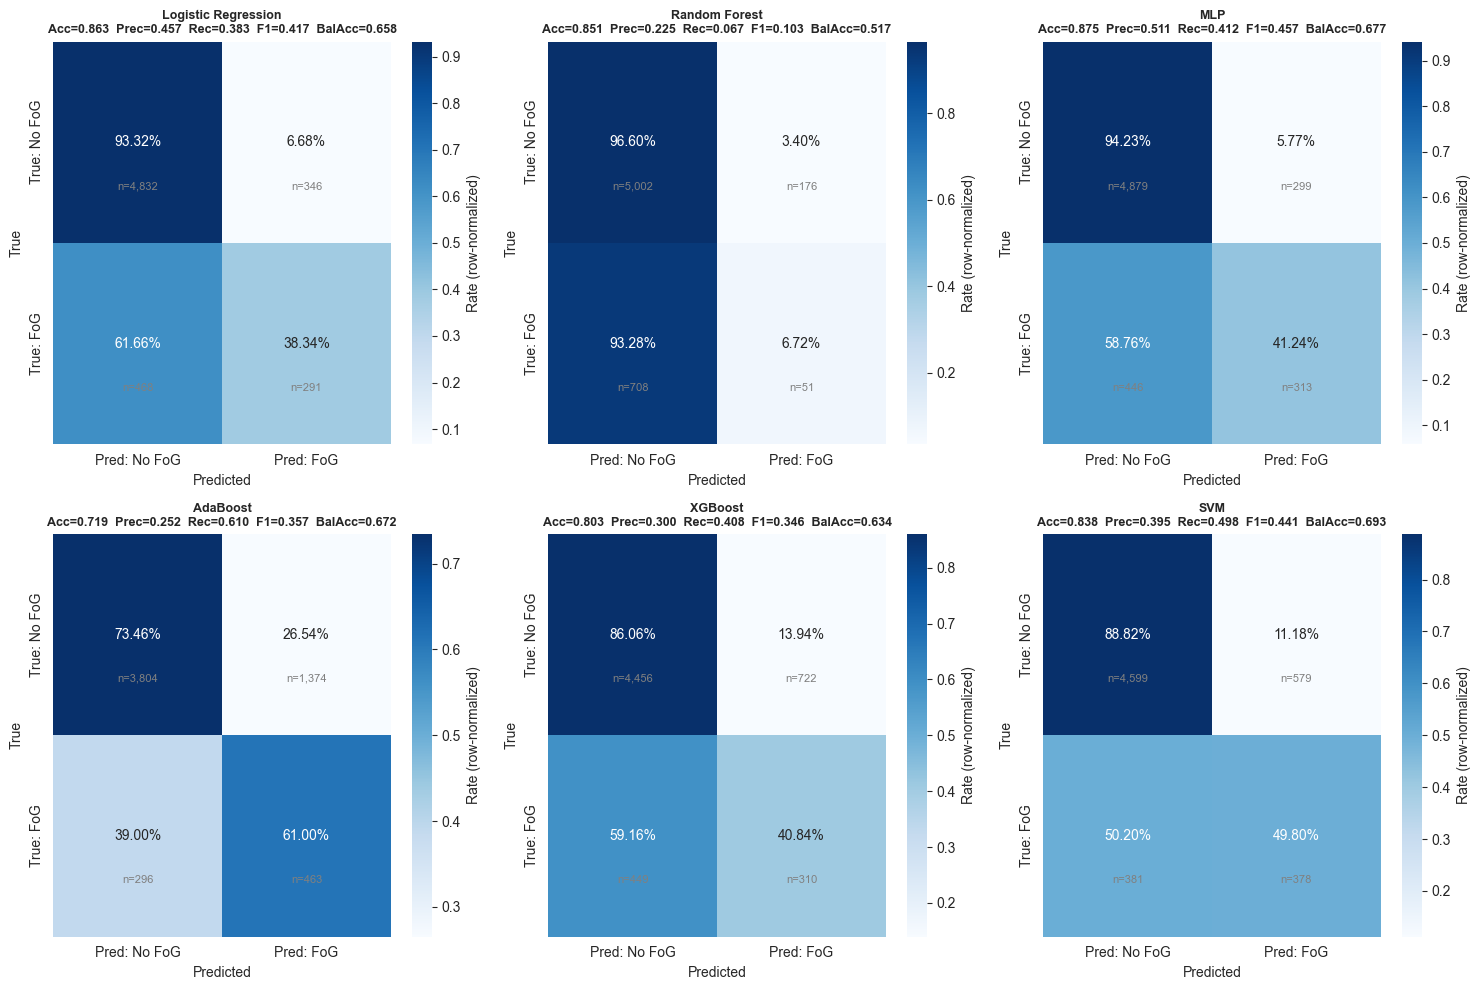

✅ Metrics and CM percentages are fully consistent (both from aggregated counts)


In [18]:
# Confusion matrices for each classifier
# NOTE: All metrics (Acc, Prec, Rec, F1, BalAcc) are derived directly from the
# aggregated cm_total, so they are fully consistent with the CM percentages.
print("=" * 90)
print("CONFUSION MATRICES - ALL CLASSIFIERS")
print("Metrics derived from aggregated counts across all folds (consistent with CM)")
print("=" * 90)

n_classifiers = len(all_results)
n_cols = 3
n_rows = (n_classifiers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_classifiers > 1 else [axes]

for idx, (clf_name, results) in enumerate(all_results.items()):
    # Accumulate confusion matrix across all folds
    cm_total = np.zeros((2, 2), dtype=int)
    for r in results:
        cm_total += r['cm']

    # Derive metrics directly from cm_total (consistent with CM visualization)
    tn, fp, fn, tp = cm_total.ravel()
    total = cm_total.sum()
    agg_accuracy  = (tp + tn) / total if total > 0 else 0.0
    agg_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    agg_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    agg_f1 = (2 * agg_precision * agg_recall / (agg_precision + agg_recall)
              if (agg_precision + agg_recall) > 0 else 0.0)
    agg_tnr     = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    agg_bal_acc = (agg_recall + agg_tnr) / 2

    # Row-normalize: each cell shows the rate within its true class
    with np.errstate(invalid='ignore'):
        cm_normalized = cm_total.astype('float') / cm_total.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)

    ax = axes[idx]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
               xticklabels=['Pred: No FoG', 'Pred: FoG'],
               yticklabels=['True: No FoG', 'True: FoG'],
               cbar_kws={'label': 'Rate (row-normalized)'},
               ax=ax)

    # Overlay raw counts
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'n={cm_total[i, j]:,}',
                    ha='center', va='center', color='gray', fontsize=8)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(
        f'{clf_name}\n'
        f'Acc={agg_accuracy:.3f}  Prec={agg_precision:.3f}  '
        f'Rec={agg_recall:.3f}  F1={agg_f1:.3f}  BalAcc={agg_bal_acc:.3f}',
        fontweight='bold', fontsize=9
    )

for idx in range(n_classifiers, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✅ Metrics and CM percentages are fully consistent (both from aggregated counts)")

In [ ]:
# Comparative visualization - Box plots for all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

metrics = ['accuracy', 'balanced_acc', 'precision', 'recall', 'specificity', 'f1']
titles  = ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]

    # Prepare data for box plot
    data_to_plot = []
    labels = []

    for clf_name, results in all_results.items():
        results_df = pd.DataFrame([
            {k: v for k, v in r.items() if k != 'cm'}
            for r in results
        ])
        if metric in results_df.columns:
            data_to_plot.append(results_df[metric].values)
        else:
            data_to_plot.append(np.array([0.0]))
        labels.append(clf_name)

    # Create box plot
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True)

    # Color boxes
    colors = ['steelblue', 'coral', 'gold', 'lightgreen', 'plum', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Classifier', fontsize=12, fontweight='bold')
    ax.set_title(f'{title} Distribution Across Folds', fontsize=13, fontweight='bold')
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

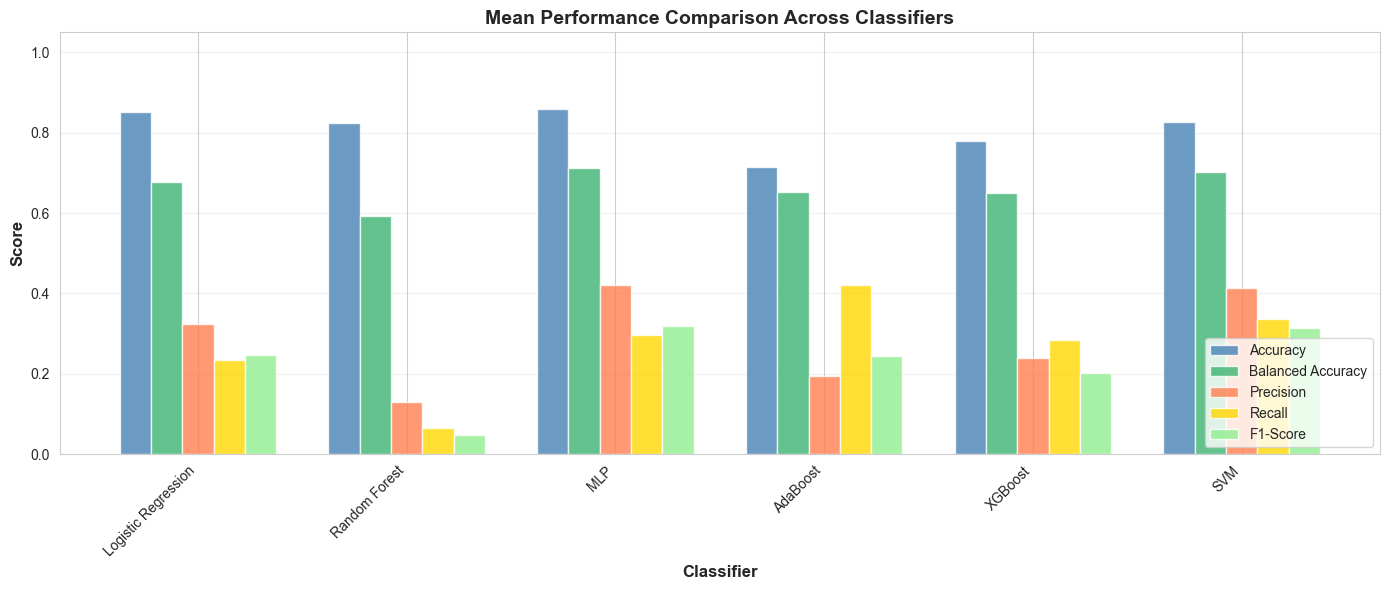

In [20]:
# Mean metrics comparison (bar plot)
fig, ax = plt.subplots(figsize=(14, 6))

# Compute means for each classifier
clf_names = list(all_results.keys())
mean_metrics = {metric: [] for metric in metrics}

for clf_name in clf_names:
    results_df = pd.DataFrame([
        {k: v for k, v in r.items() if k != 'cm'}
        for r in all_results[clf_name]
    ])
    for metric in metrics:
        mean_metrics[metric].append(results_df[metric].mean())

# Create grouped bar plot (5 metrics → width=0.15, centered at offset (i-2)*width)
x = np.arange(len(clf_names))
width = 0.15

colors_bar = ['steelblue', 'mediumseagreen', 'coral', 'gold', 'lightgreen']
for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax.bar(x + (i - 2) * width, mean_metrics[metric], width,
           label=title, color=colors_bar[i], alpha=0.8)

ax.set_xlabel('Classifier', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Mean Performance Comparison Across Classifiers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clf_names, rotation=45, ha='right')
ax.set_ylim([0, 1.05])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Results

In [21]:
# Save results for each classifier
output_dir = Path('../../outputs/daphnet_results')
output_dir.mkdir(parents=True, exist_ok=True)

print("Saving results...")
print("=" * 70)

for clf_name, results in all_results.items():
    # Create DataFrame
    results_df = pd.DataFrame([
        {k: v for k, v in r.items() if k != 'cm'}
        for r in results
    ])

    # Save to CSV
    safe_name = clf_name.replace(' ', '_').lower()
    output_path = output_dir / f'{safe_name}_loso_results.csv'
    results_df.to_csv(output_path, index=False)

    mean_f1 = results_df['f1'].mean()
    print(f"  ✓ {clf_name:20s} → {output_path.name:40s} (F1: {mean_f1:.4f})")

# Save summary comparison
summary_path = output_dir / 'summary_comparison.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\n  ✓ Summary comparison → {summary_path.name}")

print("\n" + "=" * 70)
print(f"All results saved to: {output_dir}")
print("=" * 70)

Saving results...
  ✓ Logistic Regression  → logistic_regression_loso_results.csv     (F1: 0.2478)
  ✓ Random Forest        → random_forest_loso_results.csv           (F1: 0.0487)
  ✓ MLP                  → mlp_loso_results.csv                     (F1: 0.3195)
  ✓ AdaBoost             → adaboost_loso_results.csv                (F1: 0.2440)
  ✓ XGBoost              → xgboost_loso_results.csv                 (F1: 0.2012)
  ✓ SVM                  → svm_loso_results.csv                     (F1: 0.3150)

  ✓ Summary comparison → summary_comparison.csv

All results saved to: ..\..\outputs\daphnet_results


## 6. Per-Classifier Details

Individual classifier training results.

**Classifiers:**
1. **Logistic Regression** - Linear baseline model
2. **Random Forest** - Ensemble of decision trees
3. **MLP** - Multi-layer Perceptron (Neural Network)
4. **AdaBoost** - Adaptive boosting ensemble
5. **XGBoost** - Gradient boosting (optimized)
6. **SVM** - Support Vector Machine with RBF kernel

**Pipeline structure (identical for all classifiers):**
- KNNImputer (k=5) -> RandomOverSampler -> Classifier

**Preprocessing decisions:**
- **KNNImputer**: imputes NaN with values from the 5 most similar windows (respects local feature structure, better than global median for time-series features)
- **RandomOverSampler**: handles class imbalance by duplicating minority samples (safer than SMOTE/ADASYN for extreme imbalance)

**Results location:**
- Individual classifier results: `outputs/daphnet_results/`
- Summary comparison: `outputs/daphnet_results/summary_comparison.csv`

**Next steps:**
- Hyperparameter tuning for best performers using GridSearchCV
- Feature importance analysis for tree-based models
- Statistical significance testing between classifiers
- Compare performance across all datasets

## 7. Feature Importance by Sensor

Identify which features are most discriminative for FoG detection **within each sensor location**.

Each feature is assigned to its sensor group based on the channel index (ch0-ch8) or magnitude prefix.  
Three complementary importance metrics are compared side by side:

| Method | Type | What it measures |
|--------|------|-----------------|
| **ANOVA F-Score** | Parametric, univariate | Linear separability between FoG / No-FoG distributions |
| **Mutual Information** | Non-parametric, univariate | Statistical dependency (captures non-linear relationships) |
| **RF Importance (MDI)** | Tree-based, multivariate | Mean decrease in impurity — captures feature interactions |

> **Note:** Requires `feature_scores_df`, `rf_imp_df`, and `X_all_imp` from the Feature Selection Analysis section.

In [22]:
print("=" * 80)
print("CONCLUSIONS")
print("=" * 80)

# ── 1. Best features per sensor ────────────────────────────────────────────
print("\n1. BEST FEATURES PER SENSOR")
print("   Ranked by selection frequency across LOSO folds and classifiers")
print("   (how often each feature was chosen across all classifiers × folds)\n")

n_total_runs = len(fold_dirs) * len(classifiers)
freq_df = (pd.DataFrame({'feature': list(feature_counts.keys()),
                         'count':   list(feature_counts.values())})
           .assign(pct    = lambda d: d['count'] / n_total_runs * 100,
                   sensor = lambda d: d['feature'].apply(get_sensor))
           .sort_values('pct', ascending=False))

for sensor in [s for s in sensor_col_map if s != 'Global']:
    sub = freq_df[freq_df['sensor'] == sensor].head(10)
    if sub.empty:
        continue
    print(f"  [{sensor}]")
    for _, r in sub.iterrows():
        bar = '█' * max(1, int(r['pct'] / 5))
        print(f"    {r['feature']:50s}  {r['pct']:5.1f}%  {bar}")
    print()

# ── 2. Best HP per classifier ───────────────────────────────────────────────
print("\n2. BEST HYPERPARAMETERS PER CLASSIFIER")
print("   Most frequent best values from RandomizedSearchCV across folds\n")

for clf_name, params_list in best_params_log.items():
    params_list = [p for p in params_list if p]
    if not params_list:
        continue
    df = pd.DataFrame(params_list)
    print(f"  [{clf_name}]")
    for col in df.columns:
        mc  = df[col].mode()[0]
        cnt = int((df[col] == mc).sum())
        print(f"    {col.replace('classifier__', '').replace('selector__', ''):30s}: {mc}  "
              f"(best in {cnt}/{len(params_list)} folds)")
    print()

print("=" * 80)

CONCLUSIONS

1. BEST FEATURES PER SENSOR
   Ranked by selection frequency across LOSO folds and classifiers
   (how often each feature was chosen across all classifiers × folds)

  [Ankle]
    acc_ankle_mag_kurt                                  100.0%  ████████████████████
    acc_ankle_mag_skew                                  100.0%  ████████████████████
    acc_ankle_mag_wavelet_entropy                       100.0%  ████████████████████
    ch1_peak_to_peak                                    100.0%  ████████████████████
    ch1_zero_crossing_rate                              100.0%  ████████████████████
    ch2_wavelet_entropy                                 100.0%  ████████████████████
    ch2_zero_crossing_rate                              100.0%  ████████████████████
    ch0_kurt                                            100.0%  ████████████████████
    ch1_wavelet_entropy                                 100.0%  ████████████████████
    ch0_wavelet_entropy                       

Features per sensor:
sensor
Ankle     112
Thigh     112
Trunk     112
Global      1

Global features: ['cadence']


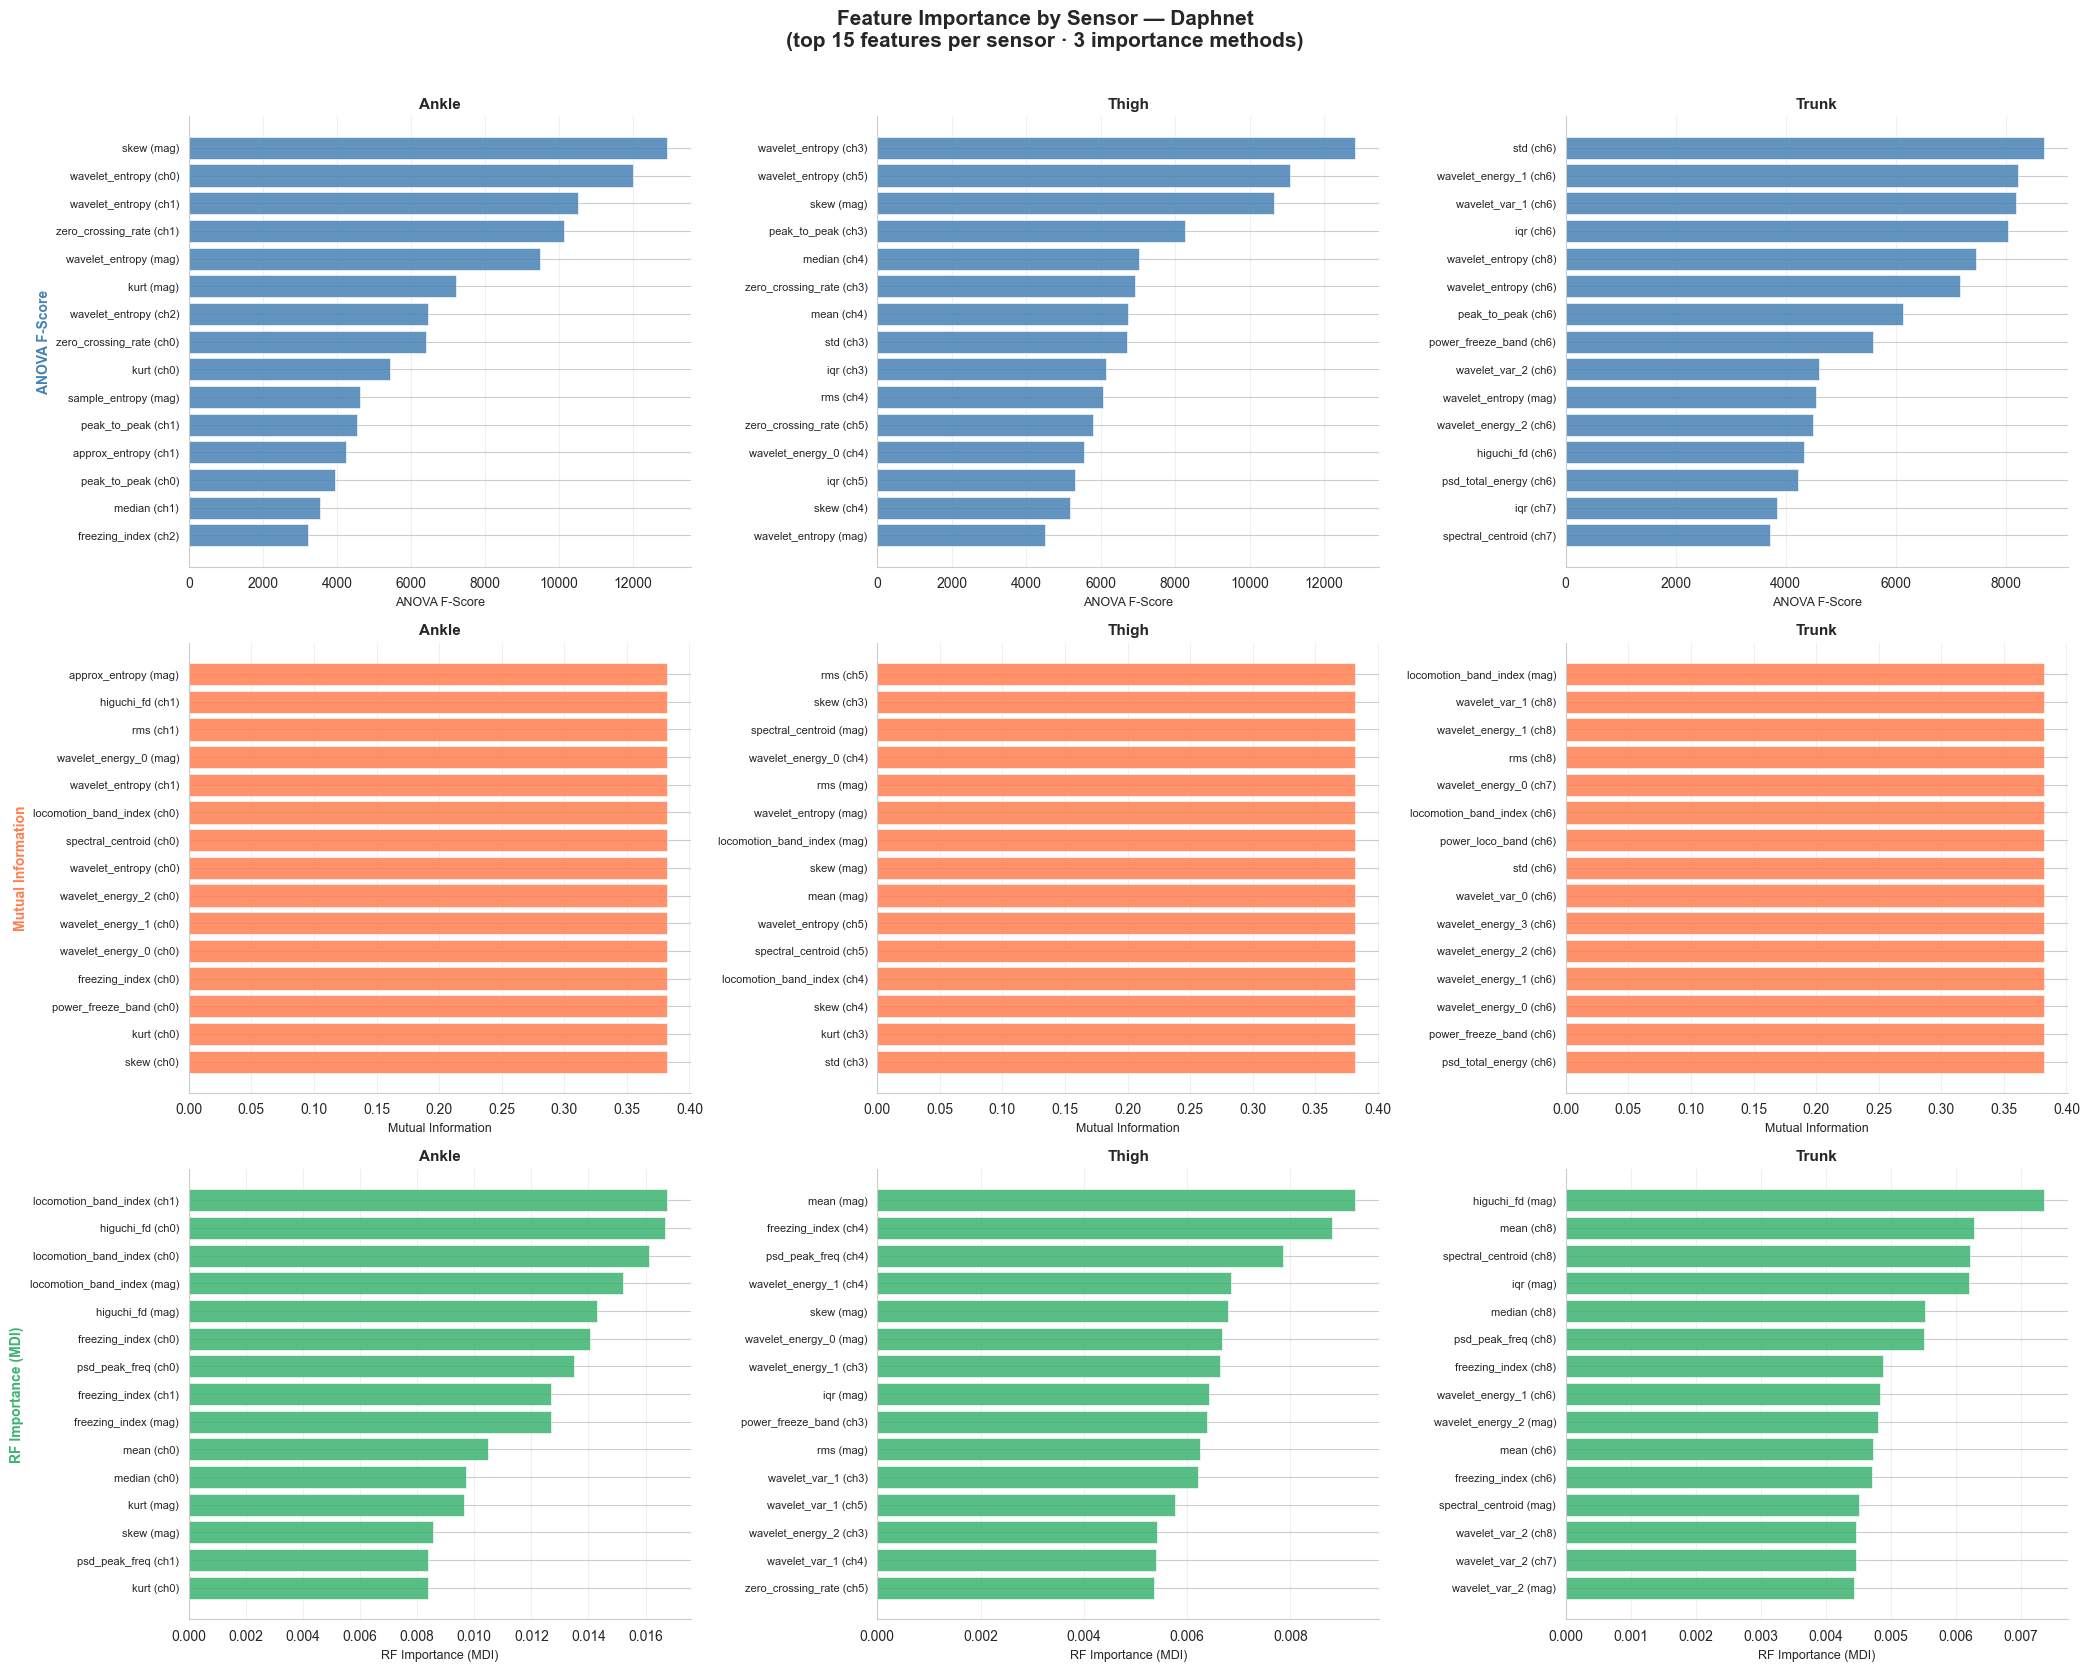

Saved → ..\..\outputs\daphnet_results\feature_importance_by_sensor.png


In [23]:
import re

# Requires: feature_scores_df, rf_imp_df, X_all_imp  (Feature Selection Analysis section)

# --- Sensor mapping: Daphnet (3 accelerometers × 3 axes) ---
CH_TO_SENSOR = {i: s for s, chs in [
    ('Ankle', [0, 1, 2]),
    ('Thigh', [3, 4, 5]),
    ('Trunk', [6, 7, 8]),
] for i in chs}
MAG_TO_SENSOR = {
    'acc_ankle_mag': 'Ankle',
    'acc_thigh_mag': 'Thigh',
    'acc_trunk_mag': 'Trunk',
}
SENSOR_LABELS = ['Ankle', 'Thigh', 'Trunk']

def get_sensor(feat):
    m = re.match(r'^ch(\d+)_', feat)
    if m: return CH_TO_SENSOR.get(int(m.group(1)), 'Global')
    for prefix, s in MAG_TO_SENSOR.items():
        if feat.startswith(prefix + '_'): return s
    return 'Global'

def short_name(feat):
    m = re.match(r'^ch(\d+)_(.+)$', feat)
    if m: return f"{m.group(2)} (ch{m.group(1)})"
    for prefix in MAG_TO_SENSOR:
        if feat.startswith(prefix + '_'): return feat[len(prefix)+1:] + ' (mag)'
    return feat

# --- Build unified feature-sensor DataFrame ---
feats  = list(X_all_imp.columns)
fs_idx = feature_scores_df.set_index('feature')
rf_idx = rf_imp_df.set_index('feature')

feat_df = pd.DataFrame({
    'feature':  feats,
    'sensor':   [get_sensor(f) for f in feats],
    'f_score':  fs_idx['f_score'].reindex(feats).fillna(0).values,
    'mi_score': fs_idx['mi_score'].reindex(feats).fillna(0).values,
    'rf_imp':   rf_idx['importance'].reindex(feats).fillna(0).values,
})

print("Features per sensor:")
print(feat_df['sensor'].value_counts().to_string())
print(f"\nGlobal features: {feat_df[feat_df['sensor'] == 'Global']['feature'].tolist()}")

# --- Plot: top-15 features per sensor per importance method ---
TOP_N   = 15
methods = [
    ('ANOVA F-Score',        'f_score',  'steelblue'),
    ('Mutual Information',   'mi_score', 'coral'),
    ('RF Importance (MDI)',  'rf_imp',   'mediumseagreen'),
]

n_rows, n_cols = len(methods), len(SENSOR_LABELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows))
fig.suptitle('Feature Importance by Sensor — Daphnet\n(top 15 features per sensor · 3 importance methods)',
             fontsize=15, fontweight='bold', y=1.01)

for row, (method_name, score_col, color) in enumerate(methods):
    for col, sensor in enumerate(SENSOR_LABELS):
        ax = axes[row, col]
        sub = (feat_df[feat_df['sensor'] == sensor]
               .nlargest(TOP_N, score_col)
               .sort_values(score_col, ascending=True))
        labels = sub['feature'].apply(short_name).tolist()
        values = sub[score_col].values

        ax.barh(range(len(sub)), values, color=color, alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel(method_name, fontsize=9)
        ax.set_title(sensor, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(method_name, fontsize=10, fontweight='bold', color=color)
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()

output_path = Path('../../outputs/daphnet_results/feature_importance_by_sensor.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {output_path}")

## 8. Sensor Fusion: Feature-Level and Decision-Level

This section implements two fusion strategies:
1. **Feature-level fusion**: Concatenate features from all sensors, apply global feature selection and train one model
2. **Decision-level fusion**: Train per-sensor models, combine via weighted soft voting and majority voting

Both approaches use LOSO with feature selection and hyperparameter tuning.

In [ ]:
# =============================================================================
# FEATURE-LEVEL FUSION: Train on ALL features concatenated from all sensors
# with global feature selection
# =============================================================================
print("=" * 70)
print("FEATURE-LEVEL FUSION")
print("All sensor features concatenated, global SelectKBest, RandomOverSampler")
print("=" * 70)

from sklearn.feature_selection import SelectKBest, f_classif

# Use the best classifier from per-sensor results (or default to RF)
feature_fusion_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, class_weight='balanced',
    random_state=42, n_jobs=-1
)

feature_fusion_results = []

for fold_dir in tqdm(fold_dirs, desc="Feature-level fusion LOSO"):
    fold_name = fold_dir.name

    X_train = clean_features(pd.read_csv(fold_dir / 'X_train_features.csv'))
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze()
    X_test  = clean_features(pd.read_csv(fold_dir / 'X_test_features.csv'))
    y_test  = pd.read_csv(fold_dir / 'y_test.csv').squeeze()

    # Remove constant features
    constant_cols = X_train.columns[X_train.nunique(dropna=False) <= 1]
    if len(constant_cols) > 0:
        X_train = X_train.drop(columns=constant_cols)
        X_test  = X_test.drop(columns=constant_cols, errors='ignore')

    if X_train.shape[1] == 0:
        continue

    # Per-subject normalization
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze().values
    X_train_arr = X_train.values.copy().astype(float)
    X_test_arr  = X_test.values.copy().astype(float)

    subj_means, subj_stds = [], []
    for subj in np.unique(subjects_train):
        mask  = subjects_train == subj
        mu    = X_train_arr[mask].mean(axis=0)
        sigma = X_train_arr[mask].std(axis=0) + 1e-8
        X_train_arr[mask] = (X_train_arr[mask] - mu) / sigma
        subj_means.append(mu)
        subj_stds.append(sigma)

    counts     = np.array([np.sum(subjects_train == s) for s in np.unique(subjects_train)])
    mean_mu    = np.average(subj_means, weights=counts, axis=0)
    mean_sigma = np.average(subj_stds,  weights=counts, axis=0)
    X_test_arr = (X_test_arr - mean_mu) / mean_sigma

    X_train_n = pd.DataFrame(X_train_arr, columns=X_train.columns)
    X_test_n  = pd.DataFrame(X_test_arr,  columns=X_test.columns)

    # Pipeline: global feature selection -> impute -> oversample -> classify
    k_global = min(45, X_train_n.shape[1])
    pipeline = ImbPipeline([
        ('selector',    SelectKBest(f_classif, k=k_global)),
        ('imputer',     KNNImputer(n_neighbors=5)),
        ('oversampler', RandomOverSampler(random_state=42)),
        ('classifier',  clone(feature_fusion_clf))
    ])

    pipeline.fit(X_train_n, y_train)

    # Threshold optimization via OOF
    n_groups = len(np.unique(subjects_train))
    inner_splits = min(3, n_groups)
    if n_groups >= 2:
        cv_inner = GroupKFold(n_splits=inner_splits)
        try:
            y_proba_oof = cross_val_predict(
                pipeline, X_train_n, y_train,
                cv=cv_inner, groups=subjects_train, method='predict_proba', n_jobs=-1
            )[:, 1]
            prec_pr, rec_pr, thresh_pr = precision_recall_curve(y_train, y_proba_oof)
            f1_arr = 2 * prec_pr * rec_pr / (prec_pr + rec_pr + 1e-9)
            best_thresh = float(np.clip(thresh_pr[np.argmax(f1_arr[:-1])], 0.05, 0.95)) if len(thresh_pr) > 0 else 0.5
        except Exception:
            best_thresh = 0.5
    else:
        best_thresh = 0.5

    pipeline.fit(X_train_n, y_train)
    y_proba_test = pipeline.predict_proba(X_test_n)[:, 1]
    y_pred = (y_proba_test >= best_thresh).astype(int)

    cm_fold = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()

    feature_fusion_results.append({
        'fold': fold_name,
        'accuracy':     accuracy_score(y_test, y_pred),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred),
        'precision':    precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall':       recall_score(y_test, y_pred, average='binary', zero_division=0),
        'specificity':  tn_f / (tn_f + fp_f) if (tn_f + fp_f) > 0 else 0.0,
        'f1':           f1_score(y_test, y_pred, average='binary', zero_division=0),
        'threshold':    best_thresh,
        'cm':           cm_fold,
    })

feature_fusion_df = pd.DataFrame(feature_fusion_results)
print(f"\nFeature-level fusion complete: {len(feature_fusion_df)} folds")

# =============================================================================
# DECISION-LEVEL FUSION: Train per-sensor models, combine via weighted voting
# =============================================================================
print("\n" + "=" * 70)
print("DECISION-LEVEL FUSION")
print("Per-sensor models (ankle/thigh/trunk), weighted soft voting")
print("=" * 70)

sensor_names = ['Ankle', 'Thigh', 'Trunk']
sensor_channel_ranges = {
    'Ankle': list(range(0, 3)),
    'Thigh': list(range(3, 6)),
    'Trunk': list(range(6, 9)),
}

decision_fusion_results = []

for fold_dir in tqdm(fold_dirs, desc="Decision-level fusion LOSO"):
    fold_name = fold_dir.name

    X_train_full = clean_features(pd.read_csv(fold_dir / 'X_train_features.csv'))
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze()
    X_test_full  = clean_features(pd.read_csv(fold_dir / 'X_test_features.csv'))
    y_test  = pd.read_csv(fold_dir / 'y_test.csv').squeeze()

    # Remove constant features
    constant_cols = X_train_full.columns[X_train_full.nunique(dropna=False) <= 1]
    if len(constant_cols) > 0:
        X_train_full = X_train_full.drop(columns=constant_cols)
        X_test_full  = X_test_full.drop(columns=constant_cols, errors='ignore')

    # Per-subject normalization
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze().values
    X_train_arr = X_train_full.values.copy().astype(float)
    X_test_arr  = X_test_full.values.copy().astype(float)

    subj_means, subj_stds = [], []
    for subj in np.unique(subjects_train):
        mask  = subjects_train == subj
        mu    = X_train_arr[mask].mean(axis=0)
        sigma = X_train_arr[mask].std(axis=0) + 1e-8
        X_train_arr[mask] = (X_train_arr[mask] - mu) / sigma
        subj_means.append(mu)
        subj_stds.append(sigma)

    counts     = np.array([np.sum(subjects_train == s) for s in np.unique(subjects_train)])
    mean_mu    = np.average(subj_means, weights=counts, axis=0)
    mean_sigma = np.average(subj_stds,  weights=counts, axis=0)
    X_test_arr = (X_test_arr - mean_mu) / mean_sigma

    X_train_n = pd.DataFrame(X_train_arr, columns=X_train_full.columns)
    X_test_n  = pd.DataFrame(X_test_arr,  columns=X_test_full.columns)

    # Build sensor-specific column maps
    all_cols = list(X_train_n.columns)
    sensor_col_indices = {}
    for sname, ch_indices in sensor_channel_ranges.items():
        sensor_cols = [c for c in all_cols if any(c.startswith(f'ch{ch}_') for ch in ch_indices)]
        # Also include magnitude features for this sensor
        sensor_key = f'acc_{sname.lower()}'
        sensor_cols += [c for c in all_cols if c.startswith(f'{sensor_key}_mag_')]
        # Also include cross-sensor correlation features
        sensor_cols += [c for c in all_cols if c.startswith('xcorr_') and sensor_key in c]
        sensor_col_indices[sname] = [c for c in sensor_cols if c in set(all_cols)]

    # Train per-sensor models and collect probabilities
    sensor_probas_test = {}
    sensor_f1_scores = {}

    n_groups = len(np.unique(subjects_train))
    inner_splits = min(3, n_groups) if n_groups >= 2 else 0

    for sname in sensor_names:
        scols = sensor_col_indices.get(sname, [])
        if len(scols) == 0:
            continue

        X_train_s = X_train_n[scols]
        X_test_s  = X_test_n[scols]

        clf_s = RandomForestClassifier(
            n_estimators=200, max_depth=15, class_weight='balanced',
            random_state=42, n_jobs=-1
        )

        pipe_s = ImbPipeline([
            ('imputer',     KNNImputer(n_neighbors=5)),
            ('oversampler', RandomOverSampler(random_state=42)),
            ('classifier',  clf_s)
        ])

        pipe_s.fit(X_train_s, y_train)

        # OOF threshold
        best_thresh_s = 0.5
        if inner_splits >= 2:
            cv_inner = GroupKFold(n_splits=inner_splits)
            try:
                y_proba_oof_s = cross_val_predict(
                    pipe_s, X_train_s, y_train,
                    cv=cv_inner, groups=subjects_train, method='predict_proba', n_jobs=-1
                )[:, 1]
                prec_pr, rec_pr, thresh_pr = precision_recall_curve(y_train, y_proba_oof_s)
                f1_arr = 2 * prec_pr * rec_pr / (prec_pr + rec_pr + 1e-9)
                if len(thresh_pr) > 0:
                    best_thresh_s = float(np.clip(thresh_pr[np.argmax(f1_arr[:-1])], 0.05, 0.95))
                # Compute OOF F1 for weighting
                y_oof_pred = (y_proba_oof_s >= best_thresh_s).astype(int)
                sensor_f1_scores[sname] = f1_score(y_train, y_oof_pred, average='binary', zero_division=0)
            except Exception:
                sensor_f1_scores[sname] = 0.1

        pipe_s.fit(X_train_s, y_train)
        y_proba_test_s = pipe_s.predict_proba(X_test_s)[:, 1]
        sensor_probas_test[sname] = y_proba_test_s

    if len(sensor_probas_test) == 0:
        continue

    # Weighted soft voting: weight by OOF F1 score
    total_weight = sum(sensor_f1_scores.get(s, 0.1) for s in sensor_probas_test)
    weighted_proba = np.zeros(len(y_test))
    for sname, proba in sensor_probas_test.items():
        w = sensor_f1_scores.get(sname, 0.1) / total_weight
        weighted_proba += w * proba

    # Use 0.5 threshold on weighted average
    y_pred_fusion = (weighted_proba >= 0.5).astype(int)

    cm_fold = confusion_matrix(y_test, y_pred_fusion, labels=[0, 1])
    tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()

    decision_fusion_results.append({
        'fold': fold_name,
        'accuracy':     accuracy_score(y_test, y_pred_fusion),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred_fusion),
        'precision':    precision_score(y_test, y_pred_fusion, average='binary', zero_division=0),
        'recall':       recall_score(y_test, y_pred_fusion, average='binary', zero_division=0),
        'specificity':  tn_f / (tn_f + fp_f) if (tn_f + fp_f) > 0 else 0.0,
        'f1':           f1_score(y_test, y_pred_fusion, average='binary', zero_division=0),
        'cm':           cm_fold,
        'sensor_weights': {s: sensor_f1_scores.get(s, 0.1) / total_weight for s in sensor_probas_test},
    })

decision_fusion_df = pd.DataFrame(decision_fusion_results)
print(f"\nDecision-level fusion complete: {len(decision_fusion_df)} folds")

In [ ]:
# =============================================================================
# FUSION RESULTS SUMMARY
# =============================================================================
def summarize_fusion(results_df, method_name):
    """Compute aggregate metrics from fusion results."""
    cm_total = np.zeros((2, 2), dtype=int)
    for _, row in results_df.iterrows():
        cm_total += row['cm']

    tn, fp, fn, tp = cm_total.ravel()
    total = cm_total.sum()
    acc = (tp + tn) / total if total > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = (rec + spec) / 2

    return {
        'Method': method_name,
        'Accuracy': acc,
        'Balanced Acc': bal_acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1': f1,
        'Total Samples': int(total),
    }

print("=" * 110)
print("FUSION AGGREGATE RESULTS")
print("=" * 110)

fusion_summaries = []

if len(feature_fusion_df) > 0:
    s = summarize_fusion(feature_fusion_df, 'Feature-level (global SelectKBest + RF)')
    fusion_summaries.append(s)

if len(decision_fusion_df) > 0:
    s = summarize_fusion(decision_fusion_df, 'Decision-level (weighted soft voting)')
    fusion_summaries.append(s)

fusion_summary_df = pd.DataFrame(fusion_summaries)
print(fusion_summary_df.to_string(index=False))
print("=" * 110)

# Per-fold details
print("\nPer-fold F1 scores:")
for method_name, df_results in [('Feature-level', feature_fusion_df), ('Decision-level', decision_fusion_df)]:
    if len(df_results) > 0:
        print(f"\n  {method_name}:")
        print(f"    F1:        {df_results['f1'].mean():.4f} +/- {df_results['f1'].std():.4f}")
        print(f"    Recall:    {df_results['recall'].mean():.4f} +/- {df_results['recall'].std():.4f}")
        print(f"    Precision: {df_results['precision'].mean():.4f} +/- {df_results['precision'].std():.4f}")
        print(f"    Bal. Acc:  {df_results['balanced_acc'].mean():.4f} +/- {df_results['balanced_acc'].std():.4f}")
        if 'specificity' in df_results:
            print(f"    Specificity: {df_results['specificity'].mean():.4f} +/- {df_results['specificity'].std():.4f}")

# Save fusion outputs
fusion_output_dir = Path('../../outputs/daphnet_results')
fusion_output_dir.mkdir(parents=True, exist_ok=True)

if len(feature_fusion_df) > 0:
    ff_save = feature_fusion_df.copy()
    ff_save['cm'] = ff_save['cm'].apply(lambda cm: str(cm.tolist()))
    ff_save.to_csv(fusion_output_dir / 'feature_level_fusion_results.csv', index=False)

if len(decision_fusion_df) > 0:
    df_save = decision_fusion_df.copy()
    df_save['cm'] = df_save['cm'].apply(lambda cm: str(cm.tolist()))
    if 'sensor_weights' in df_save.columns:
        df_save['sensor_weights'] = df_save['sensor_weights'].apply(str)
    df_save.to_csv(fusion_output_dir / 'decision_level_fusion_results.csv', index=False)

fusion_summary_df.to_csv(fusion_output_dir / 'fusion_summary.csv', index=False)
print(f"\nSaved fusion outputs to: {fusion_output_dir}")